In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import pandas as pd
import datetime as dt

In [2]:
# FEMA Tornado Tracks Historical Data
# https://gis-fema.hub.arcgis.com/datasets/e75412d18bdc469dbf89bf7e929475cc_0/about
# https://geopandas.org/en/stable/getting_started/introduction.html
file_path = r"C:\Users\308ca\Desktop\ProjectsGEE\Tornadoes4172026_4182026\TornadoesHistorical_4012001_4302024.geojson"
gdf = gpd.read_file(file_path)

gdf.head(5)

Skipping field time: unsupported OGR type: 10


,st,stf,Date_Calc,yr,mo,dy,date,tz,mag,wid,...,loss,om,stn,fc,slat,slon,elat,elon,OBJECTID,geometry
0,WI,55,"Tue, 01 May 2001 04:00:00 GMT",2001,5,1,2001-05-01,3,0,50,...,0.00,154,4,0,45.80,-92.75,45.80,-92.73,42234,"LINESTRING (-92.75 45.8, -92.73 45.8)"
1,WI,55,"Tue, 01 May 2001 04:00:00 GMT",2001,5,1,2001-05-01,3,0,25,...,0.00,177,6,0,44.75,-92.47,44.75,-92.47,42236,None
2,WI,55,"Tue, 01 May 2001 04:00:00 GMT",2001,5,1,2001-05-01,3,1,125,...,0.01,133,15,0,45.87,-89.70,45.90,-89.65,42242,"LINESTRING (-89.7 45.87, -89.65 45.9)"
3,WI,55,"Mon, 11 Jun 2001 04:00:00 GMT",2001,6,11,2001-06-11,3,0,50,...,0.00,165,3,0,44.50,-91.88,44.50,-91.87,42310,"LINESTRING (-91.88 44.5, -91.87 44.5)"
4,WI,55,"Mon, 11 Jun 2001 04:00:00 GMT",2001,6,11,2001-06-11,3,0,30,...,0.10,1015,11,0,43.72,-88.88,43.72,-88.88,42313,None


In [8]:
# Coordinate system - WGS 84 decimal degrees
print(gdf.crs)

gdf['st'].value_counts()

EPSG:4326


st
WI    586
Name: count, dtype: int64

In [9]:
# Plot of tornadoes per year and month using Date_Calc and date columns

# Datetime format conversion and consistency
# Pass:
# `format` if your strings have a consistent format;
# `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
# `format='mixed'`, and the format will be inferred for each element individually.
# dayfirst=True Ensures first number in the date string is treated as the day, not month.
gdf['Date_Calc'] = pd.to_datetime(gdf['Date_Calc'], dayfirst=True, format='mixed')

# Extract Year, Month
gdf['Year'] = gdf['Date_Calc'].dt.year
gdf['Month'] = gdf['Date_Calc'].dt.month

# Aggregate monthly, yearly data
yearly_counts = gdf.groupby('Year').size()
# We reindex months 1-12 to ensure months with zero tornadoes still appear on the chart
monthly_counts = gdf.groupby('Month').size().reindex(range(1, 13), fill_value=0)
# Intensity counts
intensity_counts = gdf.groupby('Year')['mag'].max()

# Check Date work
gdf["Date_Calc"].head(1)

0   2001-05-01 04:00:00+00:00
Name: Date_Calc, dtype: datetime64[us, UTC]

In [10]:
# https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
# Load county names for map
file_path2 = r"C:\Users\308ca\Desktop\ProjectsGEE\Tornadoes4172026_4182026\counties.zip"
counties = gpd.read_file(file_path2)

# Filter by Wisconsin State FIPS code
wi_counties = counties[counties['STATEFP'] == '55']

# Match projection to WGS-84 and map - Equidistant Cylindrical basemap projection
wi_counties = wi_counties.to_crs(epsg=4326)

wi_counties.head(3)

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
13,55,103,01581112,55103,0500000US55103,Richland,Richland County,06,H1,G4020,NaN,NaN,NaN,A,1518120284,8153422,+43.3761994,-090.4356927,"POLYGON ((-90.43147 43.55372, -90.4313 43.5537..."
65,55,047,01581083,55047,0500000US55047,Green Lake,Green Lake County,06,H1,G4020,NaN,NaN,NaN,A,905306441,79210988,+43.7802469,-088.9703796,"POLYGON ((-89.00685 43.63305, -89.01016 43.633..."
67,55,127,01581123,55127,0500000US55127,Walworth,Walworth County,06,H1,G4020,376,48580,NaN,A,1438571926,54805475,+42.6681095,-088.5417306,"POLYGON ((-88.30487 42.51653, -88.30479 42.509..."


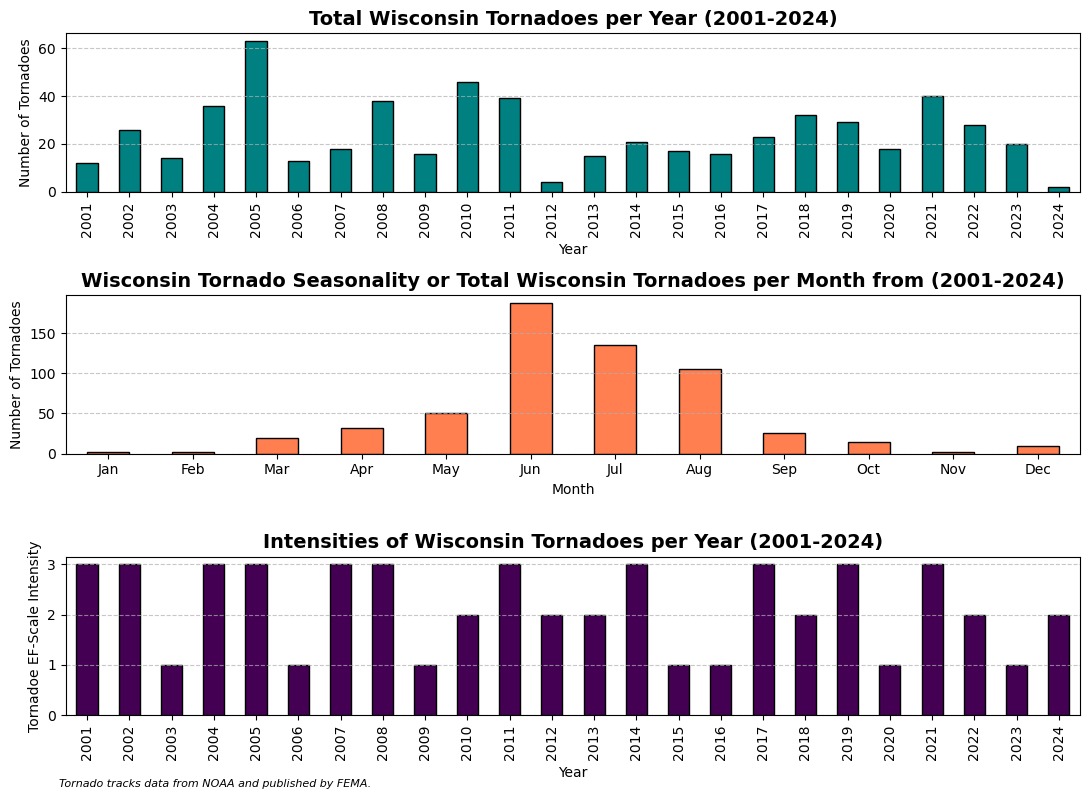

In [12]:
# Initiate blank plots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 8))

# Year Tornado Trends
yearly_counts.plot(kind='bar', ax=ax1, color='teal', edgecolor='black')
ax1.set_title('Total Wisconsin Tornadoes per Year (2001-2024)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Tornadoes')
ax1.set_xlabel('Year')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Month Tornado Seasonality
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_counts.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Wisconsin Tornado Seasonality or Total Wisconsin Tornadoes per Month from (2001-2024)', fontsize=14, fontweight='bold')
ax2.set_xticks(range(12))
ax2.set_xticklabels(month_labels, rotation=0)
ax2.set_ylabel('Number of Tornadoes')
ax2.set_xlabel('Month')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Tornado Intensities
intensity_counts.plot(kind='bar', ax=ax3, stacked=False, colormap='viridis', edgecolor='black')
ax3.set_title('Intensities of Wisconsin Tornadoes per Year (2001-2024)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Tornadoe EF-Scale Intensity')
ax3.set_xlabel('Year')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

fig.text(0.2, 0.01, 'Tornado tracks data from NOAA and published by FEMA.', 
         ha='center', fontsize=8, fontstyle='italic')

plt.tight_layout()
plt.savefig("FEMA_Tornado_Tracks_Yearly_Monthly_Intensity_Plot.png")

plt.show()

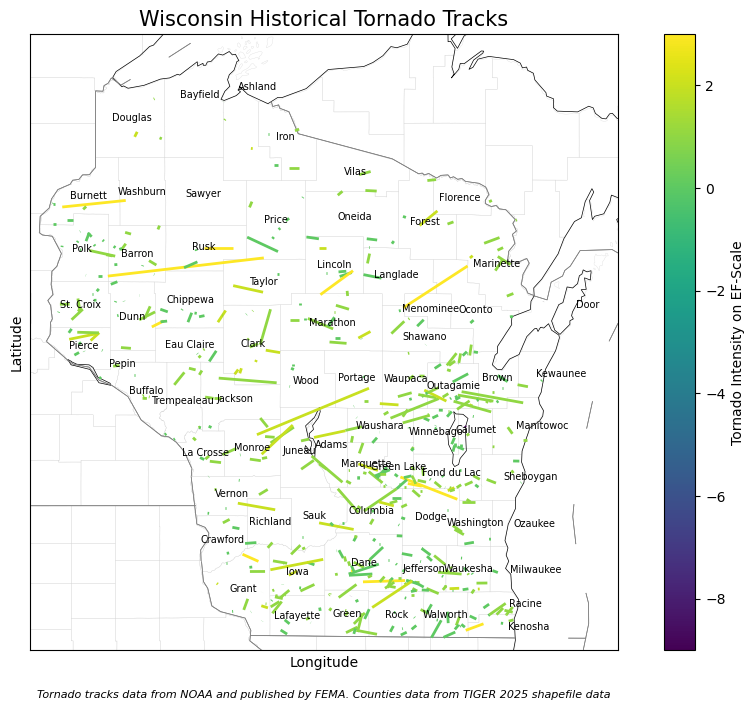

In [13]:
# Initialize blank plot for FEMA tornado tracks WI plot
fig, ax = plt.subplots(figsize=(12, 8))

# Use Equidistant Cylindrical basemap projection that matches WGS-84
m = Basemap(projection='cyl', 
            llcrnrlat=42.4, urcrnrlat=47.1,  # Wisconsin Lat/Lon bounds
            llcrnrlon=-93.0, urcrnrlon=-86.7,
            resolution='i', ax=ax)

# Add state and Canada boundaries after defining basemap from basemap import
m.drawcoastlines(linewidth=0.5, color='black')
m.drawstates(linewidth=0.5, color='gray')
m.drawcounties(linewidth=0.2, color='lightgray')

# Plot the tracks
# 'cmap' colors tracks by intensity (mag)
gdf.plot(ax=ax, 
         column='mag', 
         cmap='viridis', 
         legend=True, 
         linewidth=2,
         #alpha=.7,
         legend_kwds={'label': "Tornado Intensity on EF-Scale"})

# Add county names
for idx, row in wi_counties.iterrows():
    # Get the center of the county
    centroid = row.geometry.centroid
    # Place text (using small font and alignment for clarity)
    ax.text(centroid.x, centroid.y, row['NAME'], 
            fontsize=7, ha='center', va='center', color='black',
            clip_on=True) # clip_on ensures names don't float outside the map

# Axis titles, labels
ax.set_title('Wisconsin Historical Tornado Tracks', fontsize=15)
fig.text(0.5, 0.05, 'Tornado tracks data from NOAA and published by FEMA. Counties data from TIGER 2025 shapefile data', 
         ha='center', fontsize=8, fontstyle='italic')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.6)

plt.savefig("FEMA_Tornado_Tracks_Map.png")

plt.show()

https://www.weather.gov/grb/041726_tornadoes 
https://www.jsonline.com/story/weather/2026/04/19/nws-issues-over-90-tornado-warnings-across-wisconsin-for-april-storm/89690460007/

April 17th, 2026 was the busiest and record-setting day of about a week of intense Wisconsin storms.
Two tornadoes were reported on April 17th at an EF-1 and EF-3 intensity level. 
The state issued over a hundred tornado warnings and experienced heavy rainfall, large hail at certain locations, and flashflooding.
A record number of 26 tornado warnings in a single day since its establishment in 1995 was issues from the La Crosse NWS office.
At the peak of the storm, 45 out of 72 counties were on tornado watch.